Wspólnych zapytań: 200

Statystyki d_q:
       hit_adaptive  mrr_adaptive  mrrw_adaptive  recall_adaptive  \
count      200.0000      200.0000       200.0000         200.0000   
mean         0.0050        0.0030         0.0030           0.0150   
std          0.0707        0.0413         0.0413           0.1219   
min          0.0000       -0.1667        -0.1667           0.0000   
25%          0.0000        0.0000         0.0000           0.0000   
50%          0.0000        0.0000         0.0000           0.0000   
75%          0.0000        0.0000         0.0000           0.0000   
max          1.0000        0.5000         0.5000           1.0000   

       precision_adaptive  f1_adaptive  ndcg_adaptive  map_adaptive  \
count            200.0000     200.0000       200.0000      200.0000   
mean               0.0023       0.0042         0.0032        0.0094   
std                0.0253       0.0383         0.0420        0.0671   
min               -0.0833      -0.1071        -0.1309 

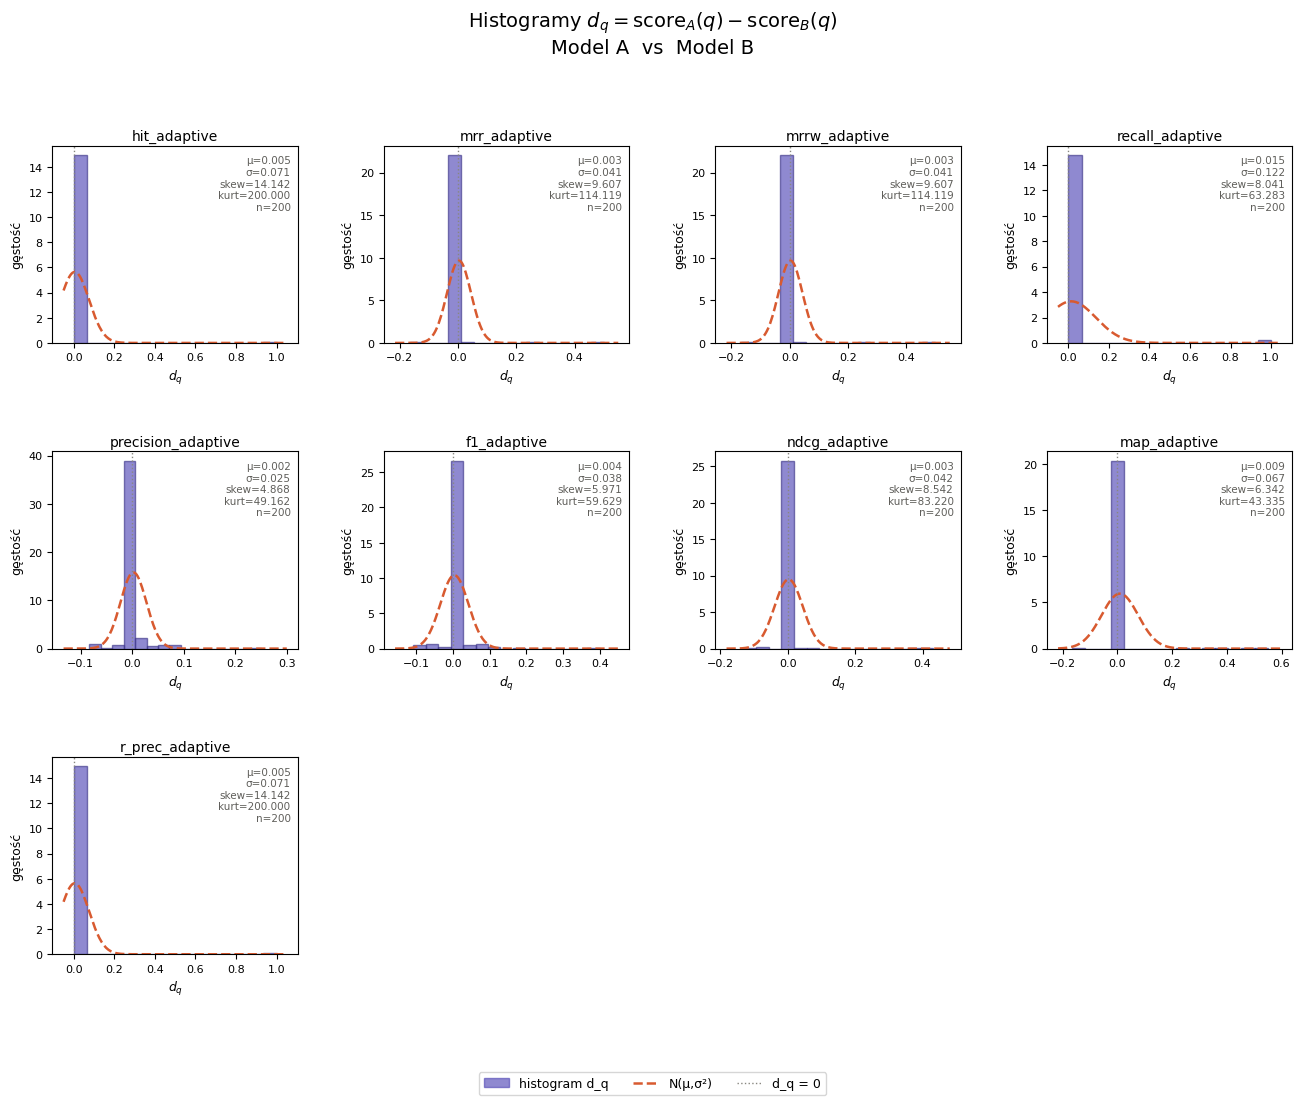

Zapisano: dq_histograms_retrieval.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import skew, kurtosis


CSV_A = "/Users/wiktoriagrodzka/moja-strona/chatbot_mini_v2/Chatbot-MiNI/src/evaluation/data/stat_test/200/retrieval_metrics_per_query_answers_google_gemini-3.5-flash_t0.2_p2_200.csv"   # <- wstaw ścieżkę do pliku A
CSV_B = "/Users/wiktoriagrodzka/moja-strona/chatbot_mini_v2/Chatbot-MiNI/src/evaluation/data/stat_test/200/retrieval_metrics_per_query_answers_openai_gpt-oss-120b_free_t0.2_p2_200.csv"   # <- wstaw ścieżkę do pliku B

MODEL_A_NAME = "Model A"
MODEL_B_NAME = "Model B"

QUERY_COL = "pytanie"           

METRICS = [
    "hit_adaptive","mrr_adaptive","mrrw_adaptive","recall_adaptive","precision_adaptive","f1_adaptive","ndcg_adaptive","map_adaptive","r_prec_adaptive"
]

METRIC_TITLES = {
    "hit_adaptive": "Hit@k",
    "mrr_adaptive": "MRR",
    "mrrw_adaptive": "MRRw",
    "recall_adaptive": "Recall",
    "precision_adaptive": "Precision",
    "f1_adaptive": "F1",
    "ndcg_adaptive": "NDCG",
    "map_adaptive": "MAP",
    "r_prec_adaptive": "R-Precision",
}

COLS_PER_ROW = 4   

df_a = pd.read_csv(CSV_A)
df_b = pd.read_csv(CSV_B)

df_a.columns = df_a.columns.str.strip()
df_b.columns = df_b.columns.str.strip()

df = df_a[[QUERY_COL] + METRICS].merge(
    df_b[[QUERY_COL] + METRICS],
    on=QUERY_COL,
    suffixes=("_A", "_B"),
)

print(f"Wspólnych zapytań: {len(df)}")

# d_q = score_A(q) - score_B(q)

dq = pd.DataFrame({metric: df[f"{metric}_A"] - df[f"{metric}_B"]
                   for metric in METRICS})

print("\nStatystyki d_q:")
print(dq.describe().round(4))

# skewness and excess kurtosis
shape_stats = pd.DataFrame({
    "skewness": dq.apply(lambda c: skew(c.dropna(), bias=False)),
    "kurtosis (excess)": dq.apply(lambda c: kurtosis(c.dropna(), fisher=True, bias=False)),
})
print("\nSkośność i kurtoza nadwyżkowa d_q:")
print(shape_stats.round(4))

# plots

n_metrics = len(METRICS)
n_rows = int(np.ceil(n_metrics / COLS_PER_ROW))

fig = plt.figure(figsize=(COLS_PER_ROW * 4, n_rows * 3.5))
fig.suptitle(
    rf"Histograms of $d_q = \mathrm{{score}}_A(q) - \mathrm{{score}}_B(q)$"
    f"\n{MODEL_A_NAME} vs {MODEL_B_NAME}",
    fontsize=14, y=1.01,
)
gs = gridspec.GridSpec(n_rows, COLS_PER_ROW, figure=fig,
                       hspace=0.55, wspace=0.35)

for idx, metric in enumerate(METRICS):
    ax = fig.add_subplot(gs[idx // COLS_PER_ROW, idx % COLS_PER_ROW])
    values = dq[metric].dropna().values
    n = len(values)

    # histogram
    bins = max(5, int(np.ceil(np.sqrt(n))))
    ax.hist(values, bins=bins, color="#534AB7", alpha=0.65, edgecolor="#3C3489",
            density=True, label="empirical")

    # normal curve
    mu, sigma = values.mean(), values.std(ddof=1)
    if sigma > 0:
        xs = np.linspace(values.min() - 0.05, values.max() + 0.05, 200)
        ys = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
        ax.plot(xs, ys, color="#D85A30", linewidth=1.8, linestyle="--", label="N(μ,σ²)")

    # abline
    ax.axvline(0, color="#888780", linewidth=1.0, linestyle=":")

    ax.set_title(METRIC_TITLES.get(metric, metric.replace("_", " ").title()), fontsize=10, pad=4)
    ax.set_xlabel(r"$d_q$", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)

    sk  = skew(values, bias=False)
    kurt = kurtosis(values, fisher=True, bias=False)   # excess kurtosis; for normal distribution = 0
    ax.text(
        0.97, 0.95,
        f"μ={mu:.3f}\nσ={sigma:.3f}\nskew={sk:.3f}\nkurt={kurt:.3f}\nn={n}",
        transform=ax.transAxes,
        fontsize=7.5, va="top", ha="right",
        color="#5f5e5a",
    )


for idx in range(n_metrics, n_rows * COLS_PER_ROW):
    fig.add_subplot(gs[idx // COLS_PER_ROW, idx % COLS_PER_ROW]).set_visible(False)

handles = [
    plt.Rectangle((0,0),1,1, color="#534AB7", alpha=0.65),
    plt.Line2D([0],[0], color="#D85A30", linewidth=1.8, linestyle="--"),
    plt.Line2D([0],[0], color="#888780", linewidth=1.0, linestyle=":"),
]
legend = fig.legend(handles, ["histogram d_q", "N(μ,σ²)", "d_q = 0"],
           loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
for text in legend.get_texts():
    text.set_color("black")

plt.savefig("dq_histograms_retrieval.png", dpi=150, bbox_inches="tight")
plt.show()

print("Zapisano: dq_histograms_retrieval.png")

Wspólnych zapytań: 200

Statystyki d_q:
           bleu    bleu_1    bleu_2    bleu_3    bleu_4  rouge_1_f  rouge_2_f  \
count  200.0000  200.0000  200.0000  200.0000  200.0000   200.0000   200.0000   
mean     0.0733    0.0327    0.0575    0.0603    0.0529     0.0747     0.0816   
std      0.1812    0.2235    0.2240    0.2202    0.2153     0.1814     0.1852   
min     -0.3911   -0.5583   -0.5891   -0.6750   -0.7200    -0.3839    -0.3433   
25%     -0.0061   -0.0805   -0.0422   -0.0194   -0.0160    -0.0250    -0.0169   
50%      0.0007    0.0000    0.0250    0.0162    0.0000     0.0384     0.0498   
75%      0.1471    0.1403    0.1506    0.1319    0.1097     0.1705     0.1612   
max      0.5947    0.7647    0.8011    0.7833    0.7016     0.7523     0.6923   

       rouge_l_f  rouge_w_f  rouge_s_f    meteor  bertscore_precision_base  \
count   200.0000   200.0000   200.0000  200.0000                  200.0000   
mean      0.0769     0.0550     0.0701    0.1031                    0.0364

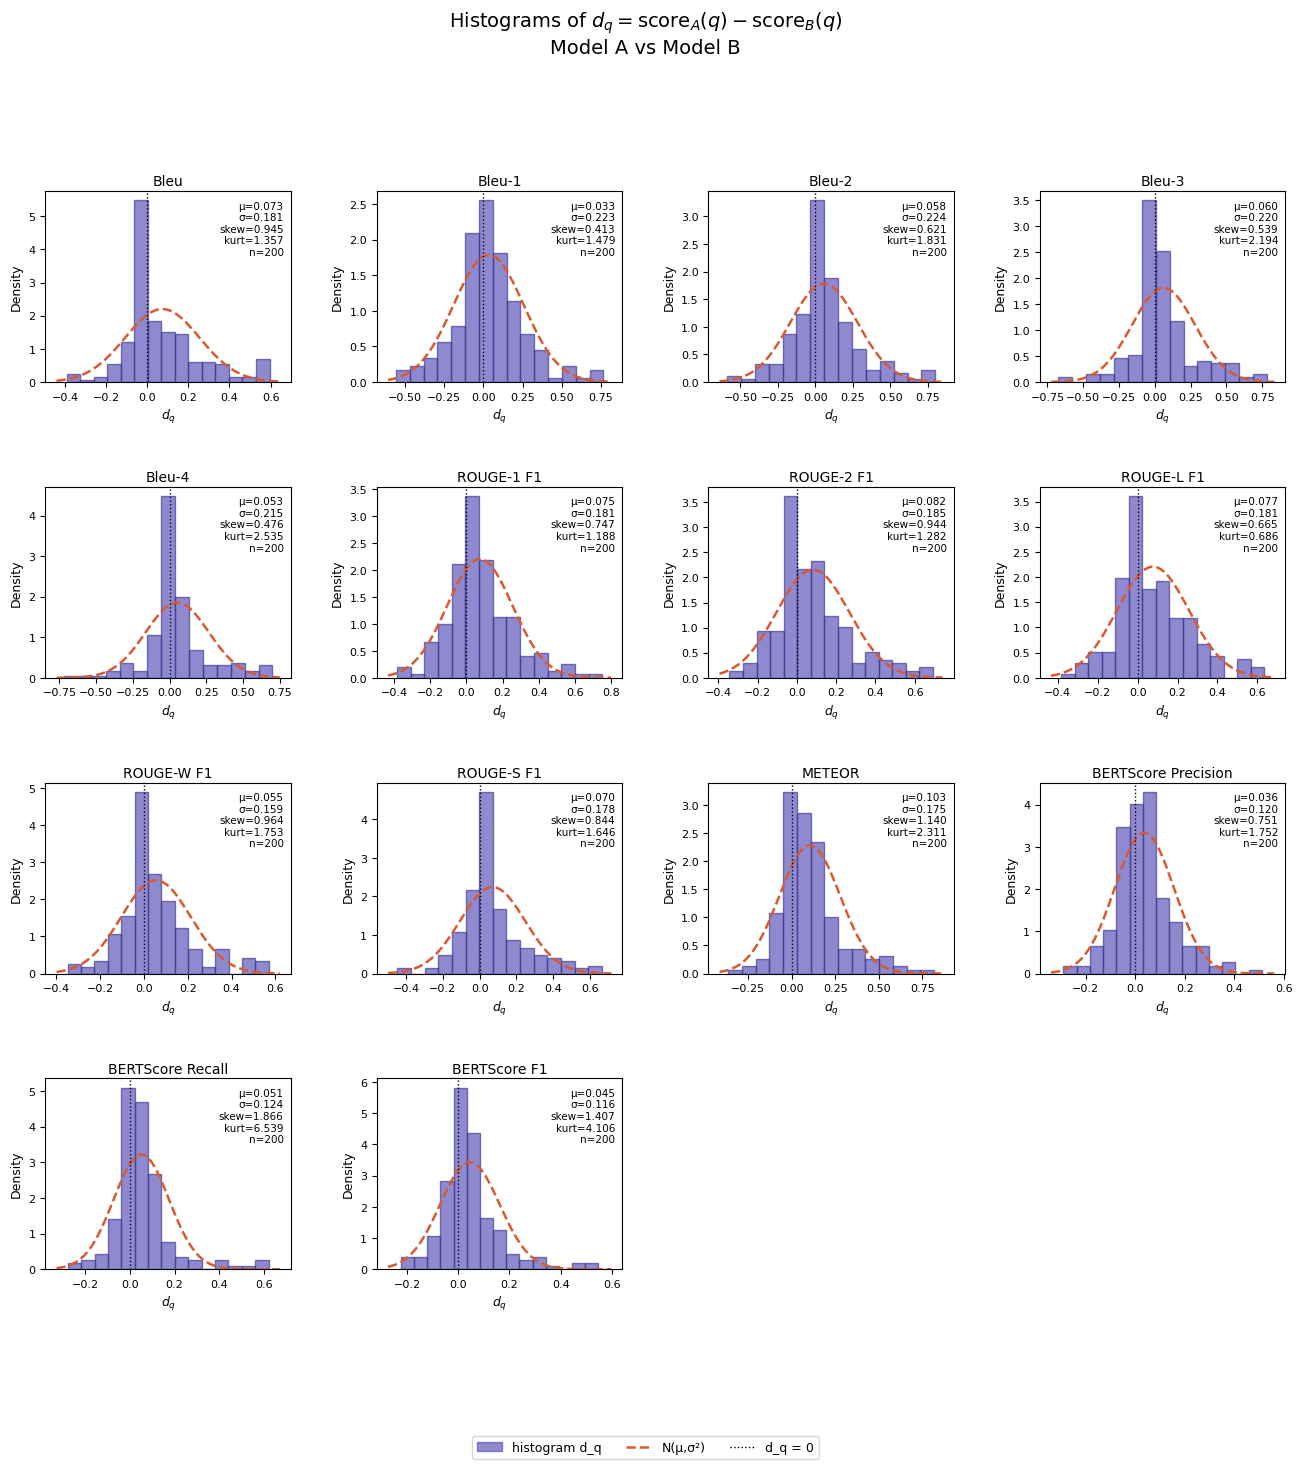

Zapisano: dq_histograms_generation.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from scipy.stats import skew, kurtosis


CSV_A = "/Users/wiktoriagrodzka/moja-strona/chatbot_mini_v2/Chatbot-MiNI/src/evaluation/data/stat_test/200/text_metrics_per_query_google_gemini-3.5-flash_t0.2_p2_200.csv"   # <- wstaw ścieżkę do pliku A
CSV_B = "/Users/wiktoriagrodzka/moja-strona/chatbot_mini_v2/Chatbot-MiNI/src/evaluation/data/stat_test/200/text_metrics_per_query_openai_gpt-oss-120b_free_t0.2_p2_200.csv"   # <- wstaw ścieżkę do pliku B

MODEL_A_NAME = "Model A"
MODEL_B_NAME = "Model B"

QUERY_COL = "pytanie"           

METRICS = [
    "bleu", "bleu_1", "bleu_2", "bleu_3", "bleu_4",
    "rouge_1_f", "rouge_2_f", "rouge_l_f", "rouge_w_f", "rouge_s_f",
    "meteor",
    "bertscore_precision_base", "bertscore_recall_base", "bertscore_f1_base",
]

METRIC_TITLES = {
    "bleu": "Bleu",
    "bleu_1": "Bleu-1",
    "bleu_2": "Bleu-2",
    "bleu_3": "Bleu-3",
    "bleu_4": "Bleu-4",
    "rouge_1_f": "ROUGE-1 F1",
    "rouge_2_f": "ROUGE-2 F1",
    "rouge_l_f": "ROUGE-L F1",
    "rouge_w_f": "ROUGE-W F1",
    "rouge_s_f": "ROUGE-S F1",
    "meteor": "METEOR",
    "bertscore_precision_base": "BERTScore Precision",
    "bertscore_recall_base": "BERTScore Recall",
    "bertscore_f1_base": "BERTScore F1",
}

COLS_PER_ROW = 4  

df_a = pd.read_csv(CSV_A)
df_b = pd.read_csv(CSV_B)

df_a.columns = df_a.columns.str.strip()
df_b.columns = df_b.columns.str.strip()

df = df_a[[QUERY_COL] + METRICS].merge(
    df_b[[QUERY_COL] + METRICS],
    on=QUERY_COL,
    suffixes=("_A", "_B"),
)

print(f"Wspólnych zapytań: {len(df)}")

# d_q = score_A(q) - score_B(q)

dq = pd.DataFrame({metric: df[f"{metric}_A"] - df[f"{metric}_B"]
                   for metric in METRICS})

print("\nStatystyki d_q:")
print(dq.describe().round(4))

# skewness and (excess kurtosis
shape_stats = pd.DataFrame({
    "skewness": dq.apply(lambda c: skew(c.dropna(), bias=False)),
    "kurtosis (excess)": dq.apply(lambda c: kurtosis(c.dropna(), fisher=True, bias=False)),
})
print("\nSkośność i kurtoza nadwyżkowa d_q:")
print(shape_stats.round(4))

# plots

n_metrics = len(METRICS)
n_rows = int(np.ceil(n_metrics / COLS_PER_ROW))

fig = plt.figure(figsize=(COLS_PER_ROW * 4, n_rows * 3.5))
fig.suptitle(
    rf"Histograms of $d_q = \mathrm{{score}}_A(q) - \mathrm{{score}}_B(q)$"
    f"\n{MODEL_A_NAME} vs {MODEL_B_NAME}",
    fontsize=14, y=1.01,
)
gs = gridspec.GridSpec(n_rows, COLS_PER_ROW, figure=fig,
                       hspace=0.55, wspace=0.35)

for idx, metric in enumerate(METRICS):
    ax = fig.add_subplot(gs[idx // COLS_PER_ROW, idx % COLS_PER_ROW])
    values = dq[metric].dropna().values
    n = len(values)

    # histogram
    bins = max(5, int(np.ceil(np.sqrt(n))))
    ax.hist(values, bins=bins, color="#534AB7", alpha=0.65, edgecolor="#3C3489",
            density=True, label="empirical")

    # normal curve
    mu, sigma = values.mean(), values.std(ddof=1)
    if sigma > 0:
        xs = np.linspace(values.min() - 0.05, values.max() + 0.05, 200)
        ys = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((xs - mu) / sigma) ** 2)
        ax.plot(xs, ys, color="#D85A30", linewidth=1.8, linestyle="--", label="N(μ,σ²)")

    # abline
    ax.axvline(0, color="#020202", linewidth=1.0, linestyle=":")

    ax.set_title(METRIC_TITLES.get(metric, metric.replace("_", " ").title()), fontsize=10, pad=4)
    ax.set_xlabel(r"$d_q$", fontsize=9)
    ax.set_ylabel("Density", fontsize=9)
    ax.tick_params(labelsize=8)

    sk  = skew(values, bias=False)
    kurt = kurtosis(values, fisher=True, bias=False)   # excess kurtosis; for normal distribution= 0
    ax.text(
        0.97, 0.95,
        f"μ={mu:.3f}\nσ={sigma:.3f}\nskew={sk:.3f}\nkurt={kurt:.3f}\nn={n}",
        transform=ax.transAxes,
        fontsize=7.5, va="top", ha="right",
        color="#000000",
    )

for idx in range(n_metrics, n_rows * COLS_PER_ROW):
    fig.add_subplot(gs[idx // COLS_PER_ROW, idx % COLS_PER_ROW]).set_visible(False)

handles = [
    plt.Rectangle((0,0),1,1, color="#534AB7", alpha=0.65),
    plt.Line2D([0],[0], color="#D85A30", linewidth=1.8, linestyle="--"),
    plt.Line2D([0],[0], color="#000000", linewidth=1.0, linestyle=":"),
]
legend = fig.legend(handles, ["histogram d_q", "N(μ,σ²)", "d_q = 0"],
           loc="lower center", ncol=3, fontsize=9,
           bbox_to_anchor=(0.5, -0.03))
for text in legend.get_texts():
    text.set_color("black")

plt.savefig("dq_histograms_generation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Zapisano: dq_histograms_generation.png")